In [1]:
import pandas as pd
import numpy as np


In [2]:
df = pd.read_excel("../Data/employee_attendance_dataset.xlsx")
df.head()


,Employee_ID,Date,Check_In_Minutes,Check_Out_Minutes,Working_Hours,Late_Minutes,Day_Of_Week
0,E101,2024-01-01,559,1062,8.38,19,0
1,E101,2024-01-02,561,1087,8.77,21,1
2,E101,2024-01-03,552,1061,8.48,12,2
3,E101,2024-01-05,570,1076,8.43,30,4
4,E101,2024-01-08,550,1073,8.72,10,0


In [3]:
print("Shape:", df.shape)
df.info()


Shape: (1256, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1256 entries, 0 to 1255
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Employee_ID        1256 non-null   object        
 1   Date               1256 non-null   datetime64[ns]
 2   Check_In_Minutes   1256 non-null   int64         
 3   Check_Out_Minutes  1256 non-null   int64         
 4   Working_Hours      1256 non-null   float64       
 5   Late_Minutes       1256 non-null   int64         
 6   Day_Of_Week        1256 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(4), object(1)
memory usage: 68.8+ KB


In [6]:
df.columns


Index(['Employee_ID', 'Date', 'Check_In_Minutes', 'Check_Out_Minutes',
       'Working_Hours', 'Late_Minutes', 'Day_Of_Week'],
      dtype='object')

In [8]:
features = [
    "Check_In_Minutes",
    "Check_Out_Minutes",
    "Working_Hours",
    "Late_Minutes",
    "Day_Of_Week"
]

X = df[features]
X.head()


,Check_In_Minutes,Check_Out_Minutes,Working_Hours,Late_Minutes,Day_Of_Week
0,559,1062,8.38,19,0
1,561,1087,8.77,21,1
2,552,1061,8.48,12,2
3,570,1076,8.43,30,4
4,550,1073,8.72,10,0


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.values)

X_scaled[:5]


array([[-0.15554486,  0.16460566,  0.23071784, -0.16177047, -1.39601988],
       [-0.10656909,  0.7640047 ,  0.64528381, -0.11259726, -0.68122128],
       [-0.32696005,  0.1406297 ,  0.33701681, -0.33387672,  0.03357732],
       [ 0.11382187,  0.50026912,  0.28386733,  0.1086822 ,  1.46317453],
       [-0.37593582,  0.42834124,  0.59213433, -0.38304993, -1.39601988]])

In [11]:
from sklearn.ensemble import IsolationForest

# Initialize Isolation Forest
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.05,   # 5% anomalies assumption
    random_state=42
)

# Fit & predict
iso_labels = iso_forest.fit_predict(X_scaled)

# Convert labels: 1 -> Normal, -1 -> Anomaly
df["IsolationForest_Result"] = ["Normal" if x == 1 else "Anomaly" for x in iso_labels]

# Show result count
df["IsolationForest_Result"].value_counts()


IsolationForest_Result
Normal     1193
Anomaly      63
Name: count, dtype: int64

In [12]:
from sklearn.svm import OneClassSVM

# Initialize One-Class SVM
oc_svm = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=0.05   # 5% anomalies
)

# Fit & predict
svm_labels = oc_svm.fit_predict(X_scaled)

# Convert labels
df["OneClassSVM_Result"] = ["Normal" if x == 1 else "Anomaly" for x in svm_labels]

# Show counts
df["OneClassSVM_Result"].value_counts()


OneClassSVM_Result
Normal     1194
Anomaly      62
Name: count, dtype: int64

In [13]:
from sklearn.neighbors import LocalOutlierFactor

# Initialize LOF
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05
)

# Fit & predict (note: LOF uses fit_predict directly)
lof_labels = lof.fit_predict(X_scaled)

# Convert labels
df["LOF_Result"] = ["Normal" if x == 1 else "Anomaly" for x in lof_labels]

# Show counts
df["LOF_Result"].value_counts()


LOF_Result
Normal     1193
Anomaly      63
Name: count, dtype: int64

In [14]:
# Combine results using majority voting

def final_decision(row):
    anomaly_count = 0
    
    if row["IsolationForest_Result"] == "Anomaly":
        anomaly_count += 1
    if row["OneClassSVM_Result"] == "Anomaly":
        anomaly_count += 1
    if row["LOF_Result"] == "Anomaly":
        anomaly_count += 1
    
    return "Anomaly" if anomaly_count >= 2 else "Normal"


df["Final_Anomaly_Result"] = df.apply(final_decision, axis=1)

# Show final counts
df["Final_Anomaly_Result"].value_counts()


Final_Anomaly_Result
Normal     1207
Anomaly      49
Name: count, dtype: int64

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


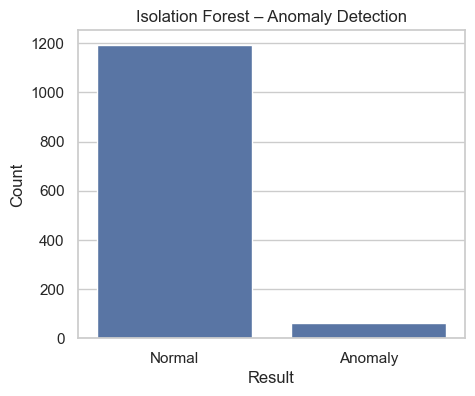

In [18]:
plt.figure(figsize=(5,4))
sns.countplot(x=df["IsolationForest_Result"])
plt.title("Isolation Forest – Anomaly Detection")
plt.xlabel("Result")
plt.ylabel("Count")
plt.show()


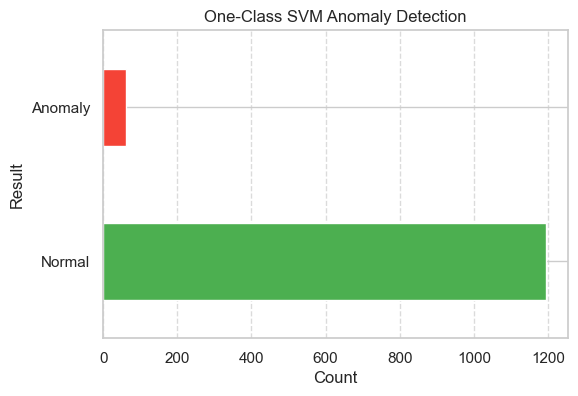

In [20]:
plt.figure(figsize=(6,4))
df["OneClassSVM_Result"].value_counts().plot(
    kind="barh",
    color=["#4CAF50", "#F44336"]
)

plt.title("One-Class SVM Anomaly Detection", fontsize=12)
plt.xlabel("Count")
plt.ylabel("Result")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()


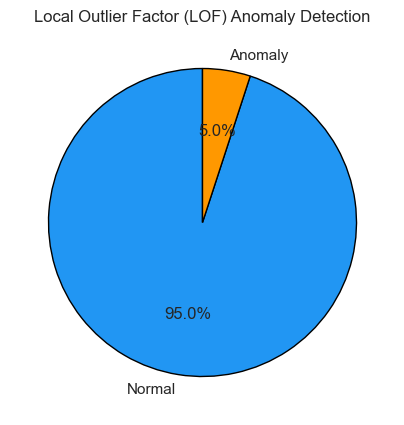

In [21]:
plt.figure(figsize=(5,5))
df["LOF_Result"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    colors=["#2196F3", "#FF9800"],
    wedgeprops={"edgecolor": "black"}
)

plt.title("Local Outlier Factor (LOF) Anomaly Detection")
plt.ylabel("")  # removes default y-label
plt.show()


In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

label_map = {"Normal": 0, "Anomaly": 1}

y_true = df["Final_Anomaly_Result"].map(label_map)

y_if  = df["IsolationForest_Result"].map(label_map)
y_svm = df["OneClassSVM_Result"].map(label_map)
y_lof = df["LOF_Result"].map(label_map)


In [23]:
metrics = {
    "Isolation Forest": [
        accuracy_score(y_true, y_if),
        precision_score(y_true, y_if),
        recall_score(y_true, y_if),
        f1_score(y_true, y_if)
    ],
    "One-Class SVM": [
        accuracy_score(y_true, y_svm),
        precision_score(y_true, y_svm),
        recall_score(y_true, y_svm),
        f1_score(y_true, y_svm)
    ],
    "LOF": [
        accuracy_score(y_true, y_lof),
        precision_score(y_true, y_lof),
        recall_score(y_true, y_lof),
        f1_score(y_true, y_lof)
    ]
}

import pandas as pd

metrics_df = pd.DataFrame(
    metrics,
    index=["Accuracy", "Precision", "Recall", "F1-Score"]
)

metrics_df


,Isolation Forest,One-Class SVM,LOF
Accuracy,0.961783,0.989650,0.937898
Precision,0.507937,0.790323,0.269841
Recall,0.653061,1.000000,0.346939
F1-Score,0.571429,0.882883,0.303571


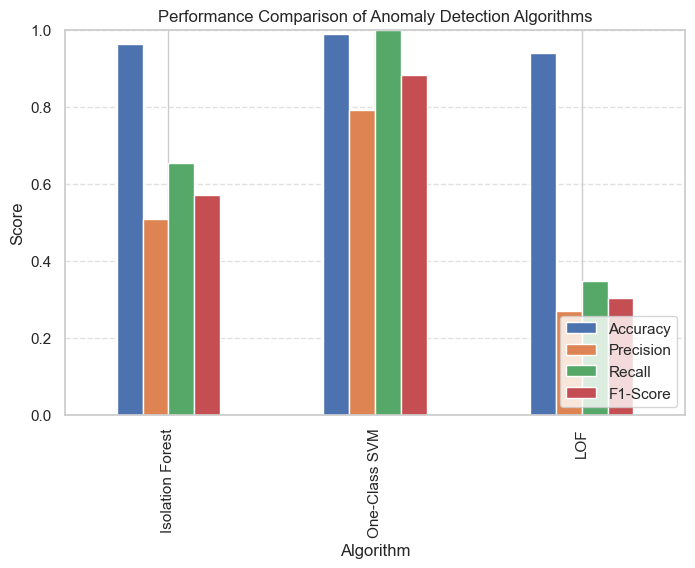

In [24]:
metrics_df.T.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Performance Comparison of Anomaly Detection Algorithms")
plt.xlabel("Algorithm")
plt.ylabel("Score")
plt.ylim(0,1)
plt.legend(loc="lower right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()


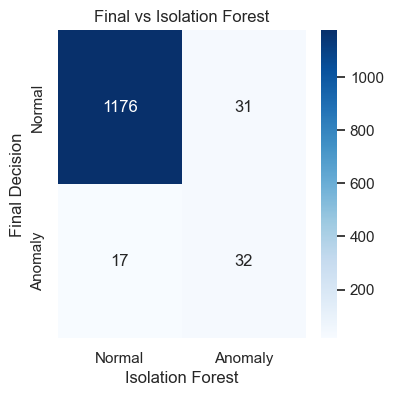

In [25]:
from sklearn.metrics import confusion_matrix

labels = [0, 1]

cm_if = confusion_matrix(y_true, y_if, labels=labels)

plt.figure(figsize=(4,4))
sns.heatmap(
    cm_if,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Anomaly"],
    yticklabels=["Normal", "Anomaly"]
)
plt.title("Final vs Isolation Forest")
plt.xlabel("Isolation Forest")
plt.ylabel("Final Decision")
plt.show()
